In [27]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_context('paper', font_scale=2., rc={"lines.linewidth": 1.75} )
sns.set_style({'font.weight': 'bold'})

# Markers
plt.rcParams['lines.markersize'] = 12
plt.rcParams['lines.linewidth'] = 2
plt.rcParams['figure.figsize'] = (8.7,6.27)

_LEGEND_MARKER_SCALE = 1.5
_MARKERS = ["v", "^", "s", "X"]

_SNS_PARAMS = {"hue":'S', "style":'S', "markers":_MARKERS, "dashes":True}

dtype = "fp16"
k = 256

In [28]:
def add_stats_siso(df, nbytes_out_dtype: int):
    # Input number of bytes per element
    df["in_bytes_per_elem"] = df["dtype"].map({"fp32": 4, "fp16": 2, "int8": 1})

    num_mask_bytes = 1 # mask has int8 dtype
    df["mem_bytes"] = (df["size"] + df["outputsize"]) * df["in_bytes_per_elem"] 
    
    df["gelemps"] = (df["size"] / 1e9) / (df["time_us"] / 1e6)
    df["bw_gbps"] = ( df["mem_bytes"] / 1e9) / (df["time_us"] / 1e6)

def add_topk_pivot_stats_siso(df):
    """Returns the bandwdith (GB/s) given size and dtype."""
    # Input number of bytes per element
    df["in_bytes_per_elem"] = df["dtype"].map({"fp32": 4, "fp16": 2, "int8": 1})

    df["mem_bytes"] = df["size"] * df["in_bytes_per_elem"] 
    df["gelemps"] = (df["size"] / 1e9) / (df["time_us"] / 1e6)
    df["bw_gbps"] = ( df["mem_bytes"] / 1e9) / (df["time_us"] / 1e6)

In [29]:
PREFIX_PATH = "../../.."

df_copy = pd.read_csv(f"{PREFIX_PATH}/bench_results_copy_{dtype}.csv")
df_copy["S"] = "memcopy"
add_stats_siso(df_copy, 2)

df_topk_pivot = pd.DataFrame()
df_topk_pivot = pd.read_csv(f"{PREFIX_PATH}/bench_results_topk_pivot_{k}_{dtype}.csv")
df_topk_pivot["S"] = f"k={k} ({dtype})"
add_topk_pivot_stats_siso(df_topk_pivot)

df = pd.concat([df_copy, df_topk_pivot])

In [30]:
df.columns

Index(['operator', 'dtype', 'size', 'density', 'outputsize', 'time_us', 'S',
       'in_bytes_per_elem', 'mem_bytes', 'gelemps', 'bw_gbps'],
      dtype='object')

/tmp/ipykernel_323196/2107445975.py:8: UserWarning: The palette list has more values (5) than needed (2), which may not be intended.
  ax = sns.lineplot(data=df, x='size', y='bw_gbps', palette=palette, **_SNS_PARAMS)
/tmp/ipykernel_323196/2107445975.py:8: UserWarning: The markers list has more values (4) than needed (2), which may not be intended.
  ax = sns.lineplot(data=df, x='size', y='bw_gbps', palette=palette, **_SNS_PARAMS)


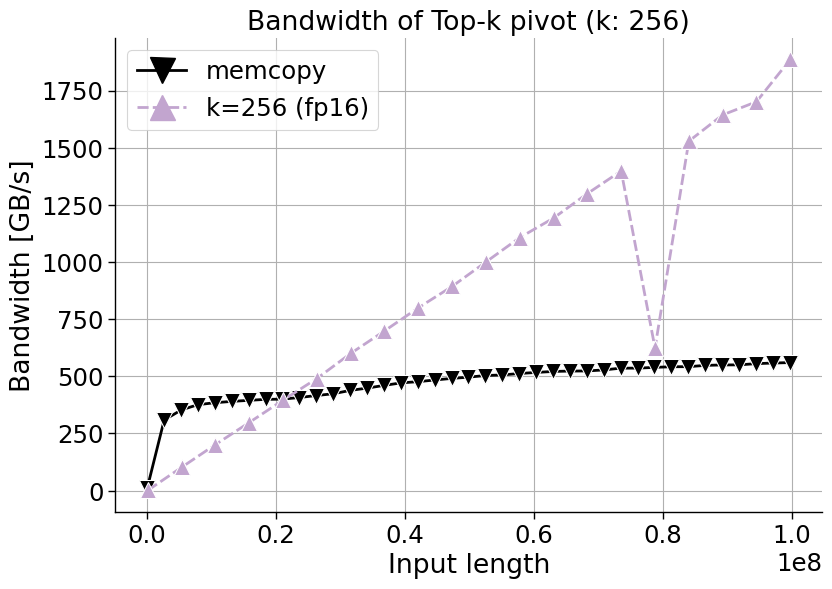

<Figure size 870x627 with 0 Axes>

In [31]:
palette = [### Colorbrewer colors
"black",
"#c2a5cf",
"#a6dba0",
"#008837",
"#7b3294",]

ax = sns.lineplot(data=df, x='size', y='bw_gbps', palette=palette, **_SNS_PARAMS)

ax.set_title(f"Bandwidth of Top-k pivot (k: {k})")
ax.set_xlabel("Input length")
ax.set_ylabel("Bandwidth [GB/s]")
sns.despine(right = True)
plt.legend(markerscale=_LEGEND_MARKER_SCALE)
plt.grid()

plt.tight_layout()

fig = ax.get_figure()
fig.savefig(f"figs/topk_pivot_{dtype}.png")
plt.show()
plt.clf()
